# Preprocessing Discover Graph text data

In [39]:
from neo4j import GraphDatabase, basic_auth
import pandas as pd
import numpy as np
import os
import json
import collections
import sklearn
import stellargraph as sg

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [40]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import tensorflow as tf


import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GAT

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, feature_extraction, model_selection
from stellargraph import datasets
from IPython.display import display, HTML
import matplotlib.pyplot as plt



In [3]:
driver = GraphDatabase.driver( "bolt://localhost:7687",  auth=basic_auth("neo4j", "nindoo123"))

# Pre-Processing Text

In [4]:
pulling_query = """\
            MATCH (a:Text)
            RETURN ID(a) AS ID, a.description AS description
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    blogs_desc = pd.DataFrame([dict(row) for row in result])
print("Shape",blogs_desc.shape)
blogs_desc.head()

Shape (381, 2)


,ID,description
0,360,"And not just in school, but at home Continue r..."
1,380,I have always wondered if a Design system shou...
2,381,Learn the basic concepts behind the most commo...
3,382,Maybe they should all meet the same fate Conti...
4,383,“The current protests are not simply about rac...


In [5]:
pulling_query = """\
            MATCH (a:INTEREST)
            RETURN ID(a) AS ID, a.description AS description
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    interests_desc = pd.DataFrame([dict(row) for row in result])
print("Shape",interests_desc.shape)
interests_desc.head()

Shape (744, 2)


,ID,description
0,0,Web development is the work involved in develo...
1,1,TypeScript is an open-source programming langu...
2,2,A programming language is a formal language co...
3,3,Not Found
4,4,"The career is an individual's metaphorical ""jo..."


In [6]:
descriptions_db = pd.concat([blogs_desc,interests_desc])
descriptions_db['description'].str.encode('utf-8')
print(descriptions_db.shape)
descriptions_db.head()

(1125, 2)


,ID,description
0,360,"And not just in school, but at home Continue r..."
1,380,I have always wondered if a Design system shou...
2,381,Learn the basic concepts behind the most commo...
3,382,Maybe they should all meet the same fate Conti...
4,383,“The current protests are not simply about rac...


In [7]:
corpus_text = ""
for index,r in descriptions_db.iterrows():
    corpus_text += r['description']
with open('data/corpus.txt','w') as t:
    t.write(corpus_text)
    t.close()

In [8]:
processed_corpus = corpus_text.translate ({ord(c): " " for c in "''!@#$%^&*()[]{};:,./<>?\|`~-=_+"})
list_corpus = corpus_text.split(' ')
print(list_corpus)

r', 'of', 'modern,', '"Madison', 'Avenue"', 'advertising.Worldwide', 'spending', 'on', 'advertising', 'in', '2015', 'amounted', 'to', 'an', 'estimated', 'US$529.43', 'billion.', "Advertising's", 'projected', 'distribution', 'for', '2017', 'was', '40.4%', 'on', 'TV,', '33.3%', 'on', 'digital,', '9%', 'on', 'newspapers,', '6.9%', 'on', 'magazines,', '5.8%', 'on', 'outdoor', 'and', '4.3%', 'on', 'radio.', 'Internationally,', 'the', 'largest', '("Big', 'Five")', 'advertising-agency', 'groups', 'are', 'Dentsu,', 'Interpublic,', 'Omnicom,', 'Publicis,', 'and', 'WPP.In', 'Latin,', 'advertere', 'means', '"to', 'turn', 'towards".Digital', 'Life', 'is', 'a', 'research', 'and', 'educational', 'program', 'about', 'radically', 'rethinking', 'of', 'the', 'human-computer', 'interactive', 'experience.', 'It', 'integrates', 'digital', 'world', '(information', '&', 'services)', 'and', 'physical', 'world', '(physical', 'objects/environment).', 'It', 'makes', 'interfaces', 'more', 'responsive', 'and', 'pr

In [9]:
vocab = list(set(list_corpus)) # This works well for a very small corpus
print(vocab)

sk).Communication', 'organizations;', 'walking', 'Solr,', 'chat', '1535', 'demonstrator', 'preview', 'roads', 'guarantee', '1920),', 'neighboring', 'Vicar', 'syndrome', 'reshaped,', 'traffic.', 'Billboard', '(now', 'legends.', 'interface.', '(User', '11:2', '"cop",', '2005', 'owner.Education', 'claims"', 'seedier', 'Discrete', 'Brazil,', 'variable,', 'sense.Blackout', 'Son', 'boycott)', 'Infrastructure,', 'effectiveness', 'own.\nAt', 'Baxter,', 'Xavier', 'Tricks', 'records', 'bars,', 'next,', 'sharing,', 'arresting.', 'behavior.\nChanging', 'Inc.,', '(431)', 'expose', '2019),', 'Employment', 'avoided', 'short-term', 'honey,', 'microscopic', 'winter', 'ISO/TC', 'e.g.', 'Queen', 'Metropolitan', 'inference.', 'newton-seconds', 'designed...We’re', 'Experience', 'phenomenon,', 'distmantle', 'misinformation', 'ethnically', 't...How', 'scaffolding', '(directly', 'morally', 'productivity.\n\nNot', 'conception,', 'Blink', '++x)\n', 'present.\nFace', 'cultures.', '(e.g.:', 'emergency', 'branches

In [10]:
word_counter = collections.Counter()
for term in list_corpus:
 
    if len(term) > 3:       word_counter.update({term: 1})
vocab = word_counter.most_common(400) # 200 Most common terms
print('Vocab Size: {}'.format(len(vocab))) 
print(word_counter.most_common(100))

Vocab Size: 400
[('that', 1084), ('with', 822), ('from', 583), ('which', 482), ('such', 443), ('data', 441), ('other', 386), ('also', 381), ('have', 363), ('used', 350), ('more', 243), ('most', 235), ('social', 228), ('been', 221), ('software', 214), ('their', 213), ('Continue', 199), ('often', 199), ('many', 194), ('reading', 193), ('including', 182), ('some', 179), ('computer', 179), ('design', 178), ('between', 176), ('into', 173), ('system', 171), ('through', 170), ('than', 170), ('using', 159), ('human', 157), ('include', 155), ('they', 151), ('This', 146), ('known', 146), ('United', 144), ('different', 143), ('called', 142), ('this', 141), ('learning', 140), ('systems', 139), ('development', 138), ('language', 137), ('time', 132), ('first', 130), ('programming', 129), ('term', 127), ('over', 125), ('information', 125), ('form', 122), ('about', 118), ('process', 118), ('based', 118), ('were', 117), ('being', 114), ('these', 109), ('research', 106), ('developed', 106), ('people', 1

In [11]:
vocab.append(('UNKNOWN', 1))
Idx = range(1, len(vocab)+1)
vocab = [t[0] for t in vocab]

Word2Idx = dict(zip(vocab, Idx))
Idx2Word = dict(zip(Idx, vocab))

Word2Idx['PAD'] = 0
Idx2Word[0] = 'PAD'
VOCAB_SIZE = len(Word2Idx)
print('Word2Idx Size: {}'.format(len(Word2Idx)))
print('Idx2Word Size: {}'.format(len(Idx2Word)))

Word2Idx Size: 402
Idx2Word Size: 402


In [12]:
with open('data/word2idx.json','w') as w:
    json.dump(Word2Idx,w)
with open('data/idx2word.json','w') as w:
    json.dump(Idx2Word,w)

In [13]:
w2idx_db = descriptions_db.copy()

In [44]:
features_length = 400
w2idx_dict = {}
for index,r in w2idx_db.iterrows():
    processed = r['description'].translate ({ord(c): " " for c in "''!@#$%^&*()[]{};:,./<>?\|`~-=_+"})
    list_doc = processed.split(' ')
    w2i_list = []
    for element in list_doc:
        if element in Word2Idx:
             w2i_list.append(Word2Idx[element])
        else: 
            w2i_list.append(Word2Idx['UNKNOWN'])
    while len(w2i_list) < features_length:
       w2i_list.append(Word2Idx['PAD'])
    if len(w2i_list) > features_length:
        w2i_list = w2i_list[:features_length]
    w2idx_dict[r['ID']] = w2i_list


# Creating StellarGraph

### Puxando Edges

In [45]:
pulling_query = """\
            MATCH (a)-->(b)
            RETURN ID(a) AS source, ID(b) AS target
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    edges_db = pd.DataFrame([dict(row) for row in result])
print(edges_db.shape)
edges_db.head()

(2982, 2)


,source,target
0,0,23
1,0,22
2,0,21
3,0,20
4,1,318


### puxando labels

In [46]:
pulling_query = """\
            MATCH (a)
            WHERE EXISTS (a.label)
            RETURN ID(a) AS source, a.label AS subject
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    label_db = pd.DataFrame([dict(row) for row in result])
labels = pd.Series(data =label_db['subject'].values, index = label_db['source'].values)
print(labels.shape)
labels.head()

(807,)


0    Programming
1    Programming
2    Programming
3    Programming
4    Programming
dtype: object

### cirando banco de dados de features w2idx

In [70]:
features_db = pd.DataFrame.from_dict(w2idx_dict,orient='index')
print(features_db.shape)
features_db.tail()

(1125, 400)


,0,1,2,3,4,5,6,7,8,9,...,390,391,392,393,394,395,396,397,398,399
1149,401,92,401,401,401,401,401,401,401,401,...,0,0,0,0,0,0,0,0,0,0
1150,401,401,401,401,401,401,401,401,401,110,...,0,0,0,0,0,0,0,0,0,0
1151,401,306,401,401,275,126,401,401,280,401,...,0,0,0,0,0,0,0,0,0,0
1152,401,401,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1153,401,340,401,401,401,401,268,53,401,401,...,0,0,0,0,0,0,0,0,0,0


### Criando grafo

In [48]:
graph = sg.StellarGraph(nodes = {"blog":features_db}, edges =  edges_db)
print(graph.info())

StellarGraph: Undirected multigraph
 Nodes: 1125, Edges: 2982

 Node types:
  blog: [1125]
    Features: float32 vector, length 400
    Edge types: blog-default->blog

 Edge types:
    blog-default->blog: [2982]
        Weights: all 1 (default)
        Features: none


In [49]:
train_subjects, test_subjects = model_selection.train_test_split(
    labels, train_size=140, test_size=None, stratify=labels
)
val_subjects, test_subjects = model_selection.train_test_split(
    test_subjects, train_size=500, test_size=None, stratify=test_subjects
)

646     Programming
680     Programming
542     Programming
1108    Programming
975     Programming
           ...     
1005             ML
602     Programming
714              ML
798     Programming
659              AI
Length: 500, dtype: object


In [50]:
from collections import Counter

Counter(train_subjects)

Counter({'Programming': 64,
         'Education': 10,
         'Society': 19,
         'ML': 33,
         'AI': 7,
         'Design': 7})

In [51]:
target_encoding = preprocessing.LabelBinarizer()

train_targets = target_encoding.fit_transform(train_subjects)
val_targets = target_encoding.transform(val_subjects)
test_targets = target_encoding.transform(test_subjects)

In [52]:
generator = FullBatchNodeGenerator(graph, method="gat")

train_gen = generator.flow(train_subjects.index, train_targets)

In [83]:
gat = GAT(
    layer_sizes=[8,train_targets.shape[1]],
    activations=["elu", "softmax"],
    attn_heads=8,
    generator=generator,
    in_dropout=0.5,
    attn_dropout=0.5,
    normalize=None,
)

In [84]:
x_inp, predictions = gat.in_out_tensors()

In [85]:
model = Model(inputs=x_inp, outputs=predictions)
model.compile(
    optimizer=optimizers.Adam(lr=0.005),
    loss=losses categorical_crossentropy,
    metrics=["acc"],
)

In [86]:
val_gen = generator.flow(val_subjects.index, val_targets)

In [87]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

if not os.path.isdir("logs"):
    os.makedirs("logs")
es_callback = EarlyStopping(
    monitor="val_acc", patience=10
)  # patience is the number of epochs to wait before early stopping in case of no further improvement
mc_callback = ModelCheckpoint(
    "models/best_model.h5", monitor="val_acc", save_best_only=True, save_weights_only=False
)

In [88]:
model.summary()

Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_13 (InputLayer)           [(1, 1125, 400)]     0                                            
__________________________________________________________________________________________________
input_15 (InputLayer)           [(1, None, 2)]       0                                            
__________________________________________________________________________________________________
input_16 (InputLayer)           [(1, None)]          0                                            
__________________________________________________________________________________________________
dropout_6 (Dropout)             (1, 1125, 400)       0           input_13[0][0]                   
____________________________________________________________________________________________

In [89]:
history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    verbose=2,
    shuffle=False,  # this should be False, since shuffling data means shuffling the whole graph
    callbacks=[es_callback,mc_callback],
)

Epoch 1/30
1/1 - 0s - loss: 12.2213 - acc: 0.1643 - val_loss: 13.2474 - val_acc: 0.1660
Epoch 2/30
1/1 - 0s - loss: 12.0432 - acc: 0.2143 - val_loss: 13.0022 - val_acc: 0.1840
Epoch 3/30
1/1 - 0s - loss: 13.2065 - acc: 0.1357 - val_loss: 13.1493 - val_acc: 0.1820
Epoch 4/30
1/1 - 0s - loss: 11.1760 - acc: 0.2429 - val_loss: 13.2301 - val_acc: 0.1780
Epoch 5/30
1/1 - 0s - loss: 11.8347 - acc: 0.2071 - val_loss: 12.9712 - val_acc: 0.1920
Epoch 6/30
1/1 - 0s - loss: 11.3878 - acc: 0.2500 - val_loss: 12.4941 - val_acc: 0.2240
Epoch 7/30
1/1 - 0s - loss: 12.2309 - acc: 0.2143 - val_loss: 12.2661 - val_acc: 0.2280
Epoch 8/30
1/1 - 0s - loss: 12.4376 - acc: 0.1929 - val_loss: 12.0681 - val_acc: 0.2460
Epoch 9/30
1/1 - 0s - loss: 12.8351 - acc: 0.1429 - val_loss: 12.3142 - val_acc: 0.2360
Epoch 10/30
1/1 - 0s - loss: 11.5077 - acc: 0.2643 - val_loss: 12.2820 - val_acc: 0.2380
Epoch 11/30
1/1 - 0s - loss: 12.8211 - acc: 0.1857 - val_loss: 12.2820 - val_acc: 0.2380
Epoch 12/30
1/1 - 0s - loss: 1

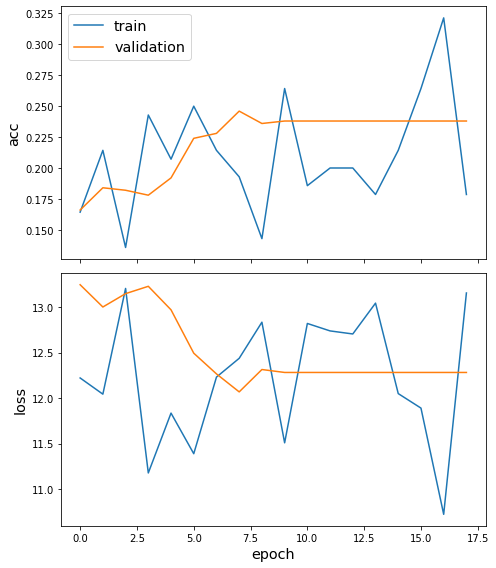

In [90]:
sg.utils.plot_history(history)

In [91]:
test_gen = generator.flow(test_subjects.index, test_targets)
test_metrics = model.evaluate(test_gen)
print("\nTest Set Metrics:")
for name, val in zip(model.metrics_names, test_metrics):
    print("\t{}: {:0.4f}".format(name, val))

1/1 [==============================] - 0s 847us/step - loss: 12.2575 - acc: 0.2395

Test Set Metrics:
	loss: 12.2575
	acc: 0.2395


In [92]:
all_nodes = labels.index
all_gen = generator.flow(all_nodes)
all_predictions = model.predict(all_gen)

In [93]:
node_predictions = target_encoding.inverse_transform(all_predictions.squeeze())

In [94]:
df = pd.DataFrame({"Predicted": node_predictions, "True": labels})
df.head(20)

,Predicted,True
0,ML,Programming
1,ML,Programming
2,ML,Programming
3,ML,Programming
4,ML,Programming
5,ML,Society
6,ML,Education
7,ML,Education
8,ML,Education
9,ML,Education


### Embeddings

In [65]:
emb_layer = next(l for l in model.layers if l.name.startswith("graph_attention"))
print(
    "Embedding layer: {}, output shape {}".format(emb_layer.name, emb_layer.output_shape)
)

Embedding layer: graph_attention_sparse_2, output shape (1, 1125, 64)


In [66]:
embedding_model = Model(inputs=x_inp, outputs=emb_layer.output)
emb = embedding_model.predict(all_gen)
X = emb.squeeze()
y = np.argmax(target_encoding.transform(labels), axis=1)

In [67]:
if X.shape[1] > 2:
    transform = TSNE  # PCA

    trans = transform(n_components=2)
    emb_transformed = pd.DataFrame(trans.fit_transform(X), index=list(graph.nodes()))
    #emb_transformed["label"] = y

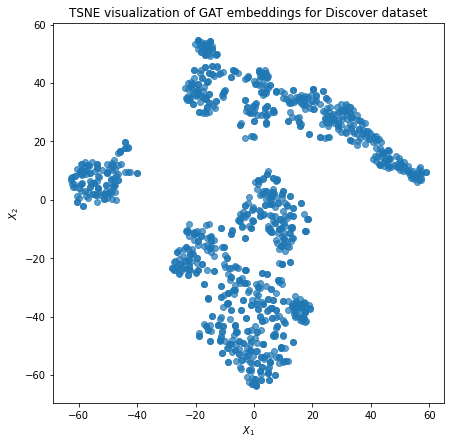

In [68]:
alpha = 0.7

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    emb_transformed[0],
    emb_transformed[1],
    #c=emb_transformed["label"].astype("category"),
    cmap="jet",
    alpha=alpha,
)
ax.set(aspect="equal", xlabel="$X_1$", ylabel="$X_2$")
plt.title(
    "{} visualization of GAT embeddings for Discover dataset".format(transform.__name__)
)
plt.show()